# Executive Summary
- The dataset suggests that mobile game monetization is driven less by overall engagement volume and more by a relatively small group of high-value players. 
- Revenue is highly concentrated, while simple engagement metrics such as session count and session length show limited linear association with spending. P
- Player characteristics and purchase timing show observable differences in revenue, but these relationships are descriptive and should not be interpreted as causal.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Milestone A: Dataset + KPI foundation

In [33]:
df = pd.read_csv("../data/game_data_clean.csv")

In [34]:
# Create subset of data for players with purchase information
purchase_df = df.dropna(
    subset=[
        "InAppPurchaseAmount", 
        "FirstPurchaseDaysAfterInstall", 
        "PaymentMethod", 
        "LastPurchaseDate"
]
).copy()

# Use df for overall player analysis and 
# purchase_df for purchase-related analysis

In [35]:
print("Total players:", len(df))
print("Players with purchase information:", len(purchase_df))
print("Players without complete purchase information:", 
    len(df) - len(purchase_df))

Total players: 3024
Players with purchase information: 2888
Players without complete purchase information: 136


In [36]:
# Total Observed Revenue
total_revenue = purchase_df["InAppPurchaseAmount"].sum()
print("Total Observed Revenue: $", total_revenue)

Total Observed Revenue: $ 296259.31


In [37]:
total_players = len(df)
total_revenue_per_player = total_revenue / total_players
print("Total Revenue per Player/ARPU: $", total_revenue_per_player)
# Again, key assumption: Not all players are paying players, 
# so this is a conservative estimate of ARPU.

Total Revenue per Player/ARPU: $ 97.96934854497354


In [38]:
avg_revenue_observed = purchase_df["InAppPurchaseAmount"].mean()
print("Average Observed Purchase Amount: $", avg_revenue_observed)

Average Observed Purchase Amount: $ 102.5828635734072


In [39]:
median_revenue_observed = purchase_df["InAppPurchaseAmount"].median()
print("Median Observed Purchase Amount: $", median_revenue_observed)

Median Observed Purchase Amount: $ 11.975000000000001


In [45]:
zero_spenders = (purchase_df["InAppPurchaseAmount"] == 0).sum()


In [40]:
paying_players = (purchase_df["InAppPurchaseAmount"] > 0).sum()

payers_percentage = (paying_players / total_players) * 100
print("Number of NON-Paying Players:", zero_spenders)
print("Number of Paying Players:", paying_players)
print("Percentage of Paying Players: {:.2f}%".format(payers_percentage))

Number of NON-Paying Players: 1
Number of Paying Players: 2887
Percentage of Paying Players: 95.47%


In [41]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Players", 
        "Players with Purchase Info",
        "Total Observed Revenue",
        "Total Revenue per Player/ARPU",
        "Average Observed Purchase Amount",
        "Median Observed Purchase Amount",
        "Observed Paying Percentage"
],
    "Value": [
        total_players,
        len(purchase_df),
        total_revenue,
        total_revenue_per_player,
        avg_revenue_observed,
        median_revenue_observed,
        payers_percentage
    ]
})

kpi_summary


,Metric,Value
0,Total Players,3024.000000
1,Players with Purchase Info,2888.000000
2,Total Observed Revenue,296259.310000
3,Total Revenue per Player/ARPU,97.969349
4,Average Observed Purchase Amount,102.582864
5,Median Observed Purchase Amount,11.975000
6,Observed Paying Percentage,95.469577


## Milestone B: Revenue Structure

In [42]:
purchase_df["InAppPurchaseAmount"].describe()

count    2888.000000
mean      102.582864
std       454.339708
min         0.000000
25%         5.987500
50%        11.975000
75%        17.762500
max      4964.450000
Name: InAppPurchaseAmount, dtype: float64

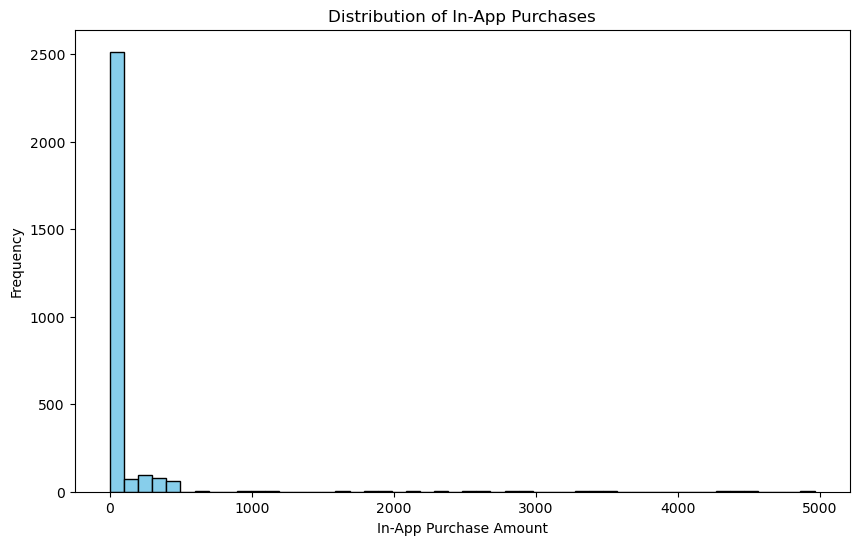

In [50]:
# Revenue data is highly skewed, with a long tail of high spenders.
plt.figure(figsize=(10, 6))

plt.hist(purchase_df["InAppPurchaseAmount"], 
bins=50, color='skyblue', edgecolor='black')

plt.xlabel("In-App Purchase Amount")
plt.ylabel("Frequency")
plt.title("Distribution of In-App Purchases")

plt.show()

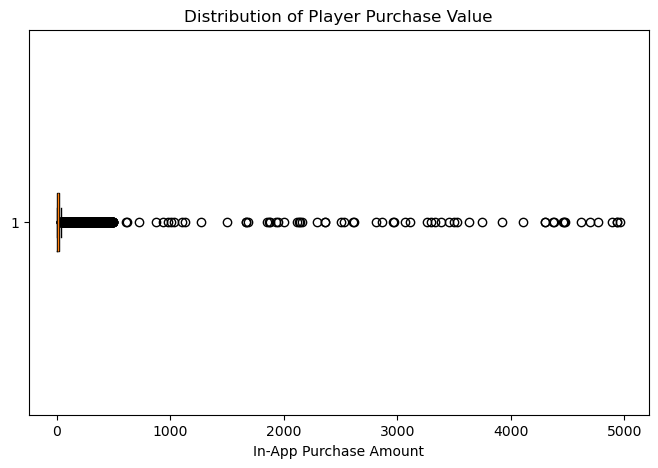

In [47]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    purchase_df["InAppPurchaseAmount"],
    vert=False
)

plt.xlabel("In-App Purchase Amount")
plt.title("Distribution of Player Purchase Value")

plt.show()

### Why is the mean higher than the median?
- The distribution of in-app purchase amounts is strongly right-skewed. 
- A relatively small number of high-spending players contribute disproportionately large amounts of revenue, which pulls the mean upward. 
- In contrast, the median represents the spending level of the middle player, so it remains relatively low when most players have low spending and only a small minority are high spenders.

In [54]:
# Revenue by Spending Segment
segment_summary = (
    df
    .groupby("SpendingSegment")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
        AvgRevenue=("InAppPurchaseAmount", "mean")
    )
    .reset_index()
)

segment_summary["PlayerShare"] = (
    segment_summary["Players"] / total_players
)

segment_summary["RevenueShare"] = (
    segment_summary["Revenue"] / segment_summary["Revenue"].sum()
)


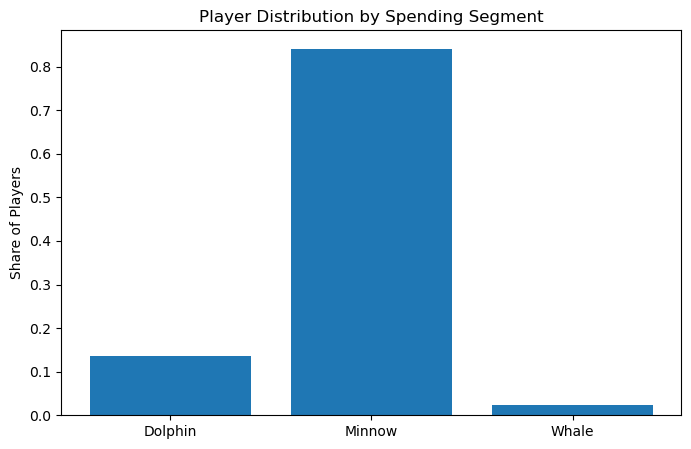

In [55]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["SpendingSegment"],
    segment_summary["PlayerShare"]
)

plt.ylabel("Share of Players")
plt.title("Player Distribution by Spending Segment")

plt.show()

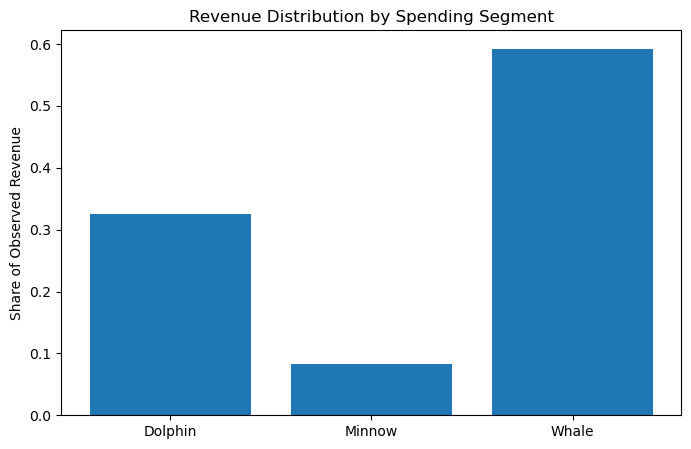

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_summary["SpendingSegment"],
    segment_summary["RevenueShare"]
)

plt.ylabel("Share of Observed Revenue")
plt.title("Revenue Distribution by Spending Segment")

plt.show()

### Though **"Whale"** only accounts for less than 5% of the Player Distribution, this spending segment contributes to almost 60% of the revenue.

## Milestone C: Behavior & Monetization

In [ ]:
# Which player characteristics are associated with higher spending?
# We have: 1) Gender, 2) Age, 3) Country, 4) Device Type, 5) Spending Segment

In [76]:
gender_summary = (
    df
    .groupby("Gender")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
        )
    .reset_index()
)

gender_summary["RevenuePerPlayer"] = (
    gender_summary["Revenue"] / gender_summary["Players"]
)

gender_summary.sort_values(
    "RevenuePerPlayer",
    ascending=False
).head(10)

,Gender,Players,Revenue,RevenuePerPlayer,PercentageDifference between Male and Female
1,Male,1810,199775.13,110.373000,34.090049
0,Female,1098,90379.23,82.312596,34.090049
2,Other,56,1940.05,34.643750,34.090049


In [72]:
device_summary = (
    df
    .groupby("Device")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
    )
    .reset_index()
)

device_summary["RevenuePerPlayer"] = (
    device_summary["Revenue"] / device_summary["Players"]
)

device_summary.sort_values(
    "RevenuePerPlayer",
    ascending=False
).head(10)

,Device,Players,Revenue,RevenuePerPlayer
1,iOS,1226,129487.62,105.617961
0,Android,1738,157721.61,90.748913


In [79]:
country_summary = (
    df
    .groupby("Country")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
        AvgRevenue=("InAppPurchaseAmount", "mean")
    )
    .reset_index()
)

country_summary["RevenueShare"] = (
    country_summary["Revenue"]
    / country_summary["Revenue"].sum()
    * 100
)

country_summary.sort_values(
    "Revenue",
    ascending=False
).head(10)


,Country,Players,Revenue,AvgRevenue,RevenueShare
10,India,242,34204.13,146.171496,11.621690
0,Afghanistan,93,20706.07,227.539231,7.035394
2,Bangladesh,101,17087.77,172.603737,5.805988
4,Canada,105,14358.44,149.567083,4.878631
19,South Korea,103,14115.99,139.762277,4.796253
6,Denmark,106,13901.79,137.641485,4.723473
9,Germany,114,13555.49,125.513796,4.605809
12,Italy,112,13549.10,127.821698,4.603638
17,Russia,93,12967.70,147.360227,4.406093
13,Japan,112,12357.39,117.689429,4.198726


In [89]:
male_vs_female = (
    (
        gender_summary.loc[
            gender_summary["Gender"] == "Male",
            "RevenuePerPlayer"
        ].values[0]
        -
        gender_summary.loc[
            gender_summary["Gender"] == "Female",
            "RevenuePerPlayer"
        ].values[0]
    )
    /
    gender_summary.loc[
        gender_summary["Gender"] == "Female",
        "RevenuePerPlayer"
    ].values[0]
    * 100
)

ios_vs_android = (
    (
        device_summary.loc[
            device_summary["Device"] == "iOS",
            "RevenuePerPlayer"
        ].values[0]
        -
        device_summary.loc[
            device_summary["Device"] == "Android",
            "RevenuePerPlayer"
        ].values[0]
    )
    /
    device_summary.loc[
        device_summary["Device"] == "Android",
        "RevenuePerPlayer"
    ].values[0]
    * 100
)

percentage_difference = pd.DataFrame({
    "Percentage Difference between Groups": [
        "Percentage difference between Male and Female players",
        "Percentage difference between iOS and Android players"
    ],
    "Values": [
        male_vs_female,
        ios_vs_android
    ]
})

percentage_difference

,Percentage Difference between Groups,Values
0,Percentage difference between Male and Female ...,34.090049
1,Percentage difference between iOS and Android ...,16.384823


### Regarding Revenue Per Player: 
- Male RevenuePerPlayer is 34% higher than female.
- IOs RevenuePerPlayer is 16% higher than Android.

In [90]:
# How does engagement correlate with revenue?
# We have 2 engagement variables: 1) SessionCount, 2) AverageSessionLength

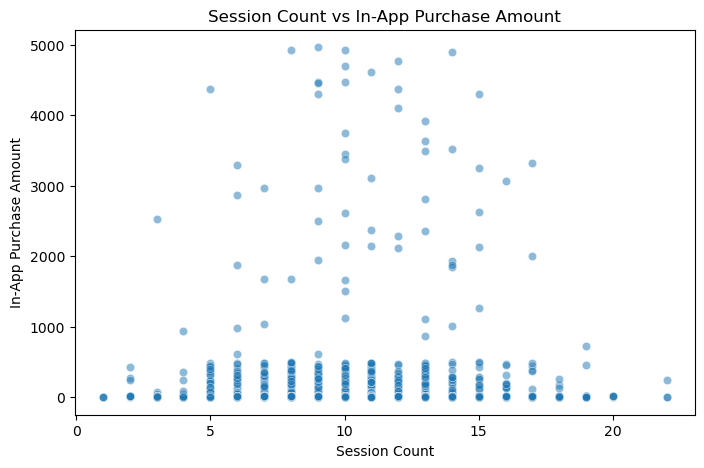

In [91]:
# SessionCount vs Revenue
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="SessionCount",
    y="InAppPurchaseAmount",
    alpha=0.5
)

plt.xlabel("Session Count")
plt.ylabel("In-App Purchase Amount")
plt.title("Session Count vs In-App Purchase Amount")
plt.show()

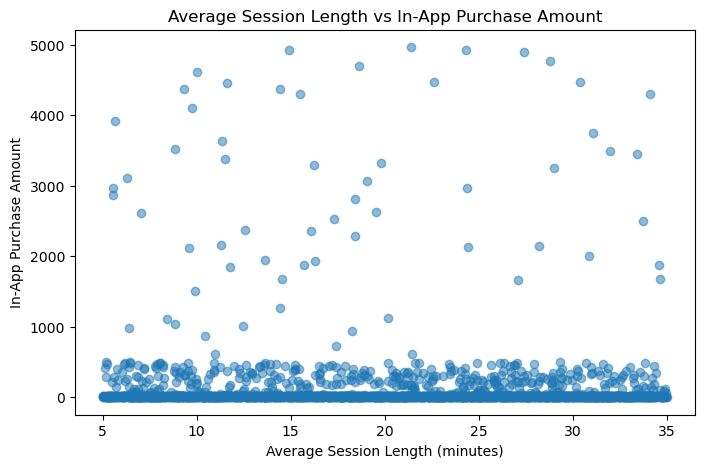

In [93]:
# AverageSesssionLength vs Revenue
plt.figure(figsize=(8, 5))
plt.scatter(
    data=df,
    x="AverageSessionLength",
    y="InAppPurchaseAmount",
    alpha=0.5
)

plt.xlabel("Average Session Length (minutes)")
plt.ylabel("In-App Purchase Amount")
plt.title("Average Session Length vs In-App Purchase Amount")
plt.show()

In [95]:
# Correlation analysis
numeric_cols = [
    "Age",
    "SessionCount",
    "AverageSessionLength",
    "InAppPurchaseAmount",
    "FirstPurchaseDaysAfterInstall"
]

correlation_matrix = (
    purchase_df[numeric_cols]
    .corr()
)

correlation_matrix

,Age,SessionCount,AverageSessionLength,InAppPurchaseAmount,FirstPurchaseDaysAfterInstall
Age,1.000000,0.027374,-0.016953,0.015536,0.011685
SessionCount,0.027374,1.000000,-0.008725,0.036289,0.010019
AverageSessionLength,-0.016953,-0.008725,1.000000,-0.028584,0.012153
InAppPurchaseAmount,0.015536,0.036289,-0.028584,1.000000,0.009652
FirstPurchaseDaysAfterInstall,0.011685,0.010019,0.012153,0.009652,1.000000


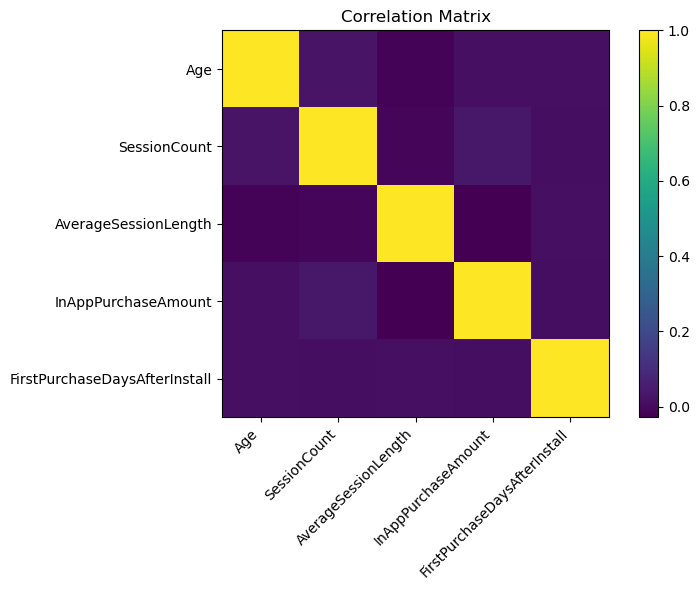

In [96]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

### Correlation analysis
- Engagement shows limited linear association with monetization. 
- Session count has only a weak relationship with in-app purchase amount, while average session length shows little apparent relationship with spending. 
- High-spending players are distributed across a broad range of engagement levels, suggesting that higher engagement alone does not necessarily translate into higher monetization.

**Engagement doesn't explain the revenue, then what are the factors that differentiate high-value players with lower-value players?**

In [ ]:
# Engagement Bucket
df["SessionBucket"] = pd.cut(
    df["SessionCount"],
    bins=[0, 5, 10, 15, 25],
    labels=[
        "1-5",
        "6-10",
        "11-15",
        "16+"

    ]
)

0        6-10
1       11-15
2        6-10
3       11-15
4        6-10
        ...  
3019     6-10
3020     6-10
3021    11-15
3022     6-10
3023     6-10
Name: SessionBucket, Length: 3024, dtype: category
Categories (4, object): ['1-5' < '6-10' < '11-15' < '16+']

In [104]:
session_summary =(
df
.groupby ("SessionBucket", observed=False)
.agg(
    Players=("UserID", "count"),
    AvgRevenue=("InAppPurchaseAmount", "mean"),
    TotalRevenue=("InAppPurchaseAmount", "sum")
    )
    .reset_index()
)

session_summary

,SessionBucket,Players,AvgRevenue,TotalRevenue
0,1-5,195,88.874550,16797.29
1,6-10,1530,96.201555,141031.48
2,11-15,1152,112.552229,122681.93
3,16+,147,110.130140,15748.61


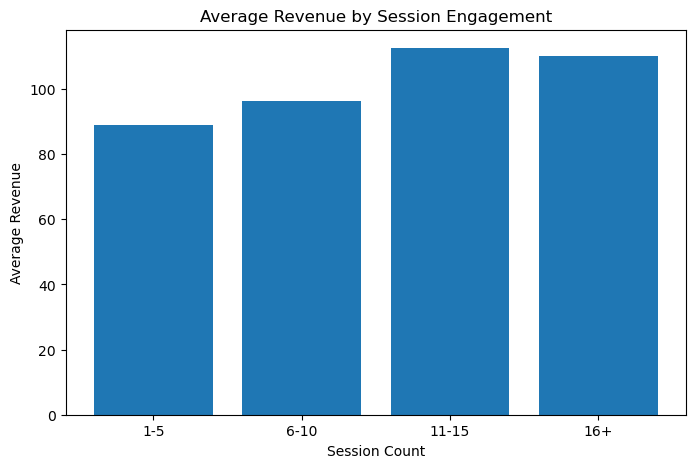

In [105]:
plt.figure(figsize=(8, 5))

plt.bar(
    session_summary["SessionBucket"].astype(str),
    session_summary["AvgRevenue"]
)

plt.xlabel("Session Count")
plt.ylabel("Average Revenue")
plt.title("Average Revenue by Session Engagement")

plt.show()

In [ ]:
# First Purchase Timing
df["FirstPurchaseBucket"] = pd.cut(
    df["FirstPurchaseDaysAfterInstall"],
    bins=[-1, 3, 7, 14, 21, 30],
    labels=[
        "0-3 days",
        "4-7 days",
        "8-14 days",
        "15-21 days",
        "22-30 days"
    ]
)
purchase_timing_summary = (
    df
    .groupby("FirstPurchaseBucket", observed=False)
    .agg(
        Players=("UserID", "count"),
        AvgRevenue=("InAppPurchaseAmount", "mean"),
        TotalRevenue=("InAppPurchaseAmount", "sum")
    )
    .reset_index()
)

purchase_timing_summary

,FirstPurchaseBucket,Players,AvgRevenue,TotalRevenue
0,0-3 days,374,84.680642,31670.56
1,4-7 days,330,92.999667,30689.89
2,8-14 days,614,124.913306,76696.77
3,15-21 days,680,73.829206,50203.86
4,22-30 days,890,120.222730,106998.23


### Players who make the first purchase 2 weeks to a month since the install date tend to contribute more to the revenue.

## Milestone D: Concetration + Business insights

In [ ]:
payment_summary = (
    df
    .groupby("PaymentMethod")
    .agg(
        Players=("UserID", "count"),
        Revenue=("InAppPurchaseAmount", "sum"),
        AvgRevenue=("InAppPurchaseAmount", "mean")
    )
    .reset_index()
)

payment_summary.sort_values(
    "Revenue",
    ascending=False
)

,PaymentMethod,Players,Revenue,AvgRevenue
3,Debit Card,433,55909.54,129.121339
6,Paypal,401,48349.50,120.572319
4,Gift Card,422,43928.45,104.095853
1,Carrier Billing,417,41372.88,99.215540
5,Google Pay,431,38505.91,89.340858
2,Credit Card,410,37564.63,91.621049
0,Apple Pay,374,30628.40,81.894118


### Different Payment Methods don't have an asssociation with the Average Revenue. Assumptions:
### Different Payment Method don't such wide gaps between AveRevenue. 
### And the gaps in AvgRevenue share patterns with gaps between number of players and revenue.

In [ ]:
# Top Players / Revenue Concentration
# How concentrated is revenue among high-value players?

In [115]:
top_players = (
    df[
        ["UserID", "SpendingSegment", "SessionCount",
         "AverageSessionLength", "InAppPurchaseAmount"]
    ]
    .sort_values(
        "InAppPurchaseAmount",
        ascending=False
    )
)

top_players.head(20)

,UserID,SpendingSegment,SessionCount,AverageSessionLength,InAppPurchaseAmount
59,b5c61dc0-138d-4d49-ae4a-c4ca75787cb2,Whale,9,21.42,4964.45
2028,9ce85d56-3f8f-431a-b0bf-eec096811b39,Whale,8,14.91,4931.98
760,a8881761-c5ca-4ded-ad96-81e76b2f04e1,Whale,10,24.31,4930.28
2563,3adbf004-12bb-4abc-985a-ec2c3e399704,Whale,14,27.42,4893.16
2304,a9f827e9-f212-47ab-8c8a-81e6b6d7145d,Whale,12,28.80,4770.77
952,69221c7c-c50f-4b3f-a67f-3c1450e4f6d8,Whale,10,18.63,4700.56
1212,af42adc7-ff91-418f-935e-b3b2d0827a45,Whale,11,9.99,4619.48
644,56824487-498c-4c14-a94b-1bf6e680769c,Whale,9,22.62,4475.47
2829,cb7c4c69-eda2-4c2a-a4f2-45f16a8bf100,Whale,10,30.40,4471.87
2880,5b59b39a-26b8-40b7-941d-c07fb6eac6af,Whale,9,11.59,4456.30


In [123]:
# Top 1%
top_1_percent_n = max(1, int(len(df) * 0.01))
top_1_revenue_share = (
    top_players.head(top_1_percent_n)["InAppPurchaseAmount"].sum()
    / df["InAppPurchaseAmount"].sum()
)

top_1_revenue_share*100

np.float64(40.052959010807115)

In [124]:
# Top 5%
top_5_percent_n = max(1, int(len(df) * 0.05))
top_5_revenue_share = (
    top_players.head(top_5_percent_n)["InAppPurchaseAmount"].sum()
    / df["InAppPurchaseAmount"].sum()
)

top_5_revenue_share*100

np.float64(72.21008852008734)

### Revenue Concentration
- Observed rvenue is highly concentrated among a small proportion of players. 
- The top 1% of players account for approximately 40.1% of observed revenue, while the top 5% account for approximately 72.2%.

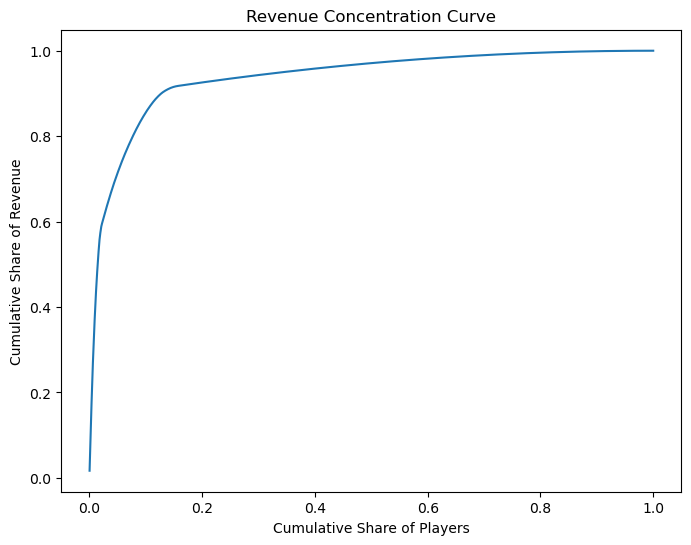

In [125]:
revenue_sorted = np.sort(
    df["InAppPurchaseAmount"].dropna().values
)[::-1]

cumulative_revenue = np.cumsum(revenue_sorted)

cumulative_revenue_share = (
    cumulative_revenue /
    cumulative_revenue[-1]
)

player_share = (
    np.arange(1, len(revenue_sorted) + 1)
    / len(revenue_sorted)
)

plt.figure(figsize=(8, 6))

plt.plot(
    player_share,
    cumulative_revenue_share
)

plt.xlabel("Cumulative Share of Players")
plt.ylabel("Cumulative Share of Revenue")
plt.title("Revenue Concentration Curve")

plt.show()


## Key findings - Recap:

### 1. Monetization is highly concentrated

A small proportion of players generates a disproportionately large share of observed revenue. Whales represent only ~2.2% of players but contribute ~59.3% of revenue, while the top 5% of players generate ~72.2%.

### 2. Revenue is strongly right-skewed
Most players have relatively low spending, while a small number of high-spending players pull the mean substantially above the median.

### 3. Engagement alone does not strongly distinguish monetization
Session count has only a weak linear association with IAP amount, while average session length shows little apparent linear relationship with spending.

### 4. Player characteristics are associated with different revenue levels
Male players show approximately 34% higher observed revenue per player than female players, while iOS players show approximately 16% higher observed revenue per player than Android players.

### 5. Monetization patterns vary by purchase timing, but less by payment method
Players whose first purchase occurs 15–30 days after installation show higher average revenue in this dataset, whereas average revenue varies relatively little across payment methods.

...